#### Objective

This notebook aims to explore customer behavior, sales performance, product trends, seller efficiency, payment preferences, shipment performance, returns, and customer reviews.
The analyses performed in this notebook will help answer key business questions and generate actionable insights to support strategic decision-making.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

plt.rcParams["axes.grid"] = False
sns.set_style("white")

In [2]:
customers = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Customers.csv")
orders = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Orders.csv")
order_items = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\OrderItems.csv")
products = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Products.csv")
categories = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Categories.csv")
payments = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Payments.csv")
reviews = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Reviews.csv")
returns = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Returns.csv")
shipments = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Shipments.csv")
sellers = pd.read_csv("D:\Flipkart sales analytics\cleaned_dataset\Sellers.csv")

In [3]:
## convert datatype of date columns into datetime
date_tables = {
    "Orders" : orders,
    "Shipments" : shipments,
    "Reviews" : reviews,
    "Returns" : returns
}

for name, df in date_tables.items():
    for col in df.columns:
        col_lower = col.lower()
        if (
            col_lower.endswith("_date")
            or col_lower.endswith("_time")
            or col_lower == "date"
            or col_lower == "time"
        ):
            print(f"Checking {name} -> {col}")

            df[col] = pd.to_datetime(df[col], errors="coerce")

Checking Orders -> order_date
Checking Shipments -> dispatch_date
Checking Shipments -> delivery_date
Checking Reviews -> review_date
Checking Returns -> return_date


### section 1 : business overview

In [4]:
#Q1: How many customers does flipkart serve
total_customers = customers["customer_id"].nunique()

print(f"Total Customers : {total_customers:,}")
## Business Insight
# The customer base represents the total number of unique buyers available for retention and loyalty strategies.

## Recommendation
# Focus on increasing repeat purchases while continuously acquiring new customers.

Total Customers : 25,000


In [5]:
#Q2: How many orders have placed?
total_orders = orders["order_id"].nunique()
print(f"total orders : {total_orders:,}")

total orders : 120,000


In [6]:
#Q3: How many products are being sold?
total_products = products["product_id"].nunique()
print(f"Total Products : {total_products:,}")

Total Products : 8,000


In [7]:
#Q4: How many sellers are active?
total_sellers = sellers["seller_id"].nunique()

print(f"Total Sellers : {total_sellers:,}")

Total Sellers : 500


In [8]:
#Q5: What is the total revenue generated?
#merge required tables
sales = (
    order_items
    .merge(
        products,
        on="product_id",
        how="left"
    )
)

#revenue calculations
sales["Revenue"] = (
    sales["selling_price_x"] *
    sales["quantity"]
)

# total revenue
total_revenue = sales["Revenue"].sum()

print(f"Total Revenue : ₹{total_revenue/1e6:,.2f}M")

print(f"The marketplace generated {total_revenue/1e6:,.0f} million in revenue.")

"""
Business Insight
Revenue indicates the overall sales performance and marketplace scale
"""

Total Revenue : ₹3,948.93M
The marketplace generated 3,949 million in revenue.


'\nBusiness Insight\nRevenue indicates the overall sales performance and marketplace scale\n'

In [9]:
sales.head()

,order_item_id,order_id,product_id,seller_id,quantity,discount_pct,shipping_charges,selling_price_x,line_revenue,category_id,brand_name,product_name,mrp,cost_price,weight_g,length_cm,height_cm,width_cm,launch_month,selling_price_y,product_rating_avg,Revenue
0,OI000000001,ORD0088068,PROD006904,SEL0352,4,10.04,232.88,2524.30,10330.08,CAT012,Tata,Product_006904,3068.94,1821.36,1852,52.9,30.8,48.4,1,2524.30,4.4,10097.20
1,OI000000002,ORD0079822,PROD003468,SEL0372,1,42.16,100.82,2881.73,2982.55,CAT004,Fastrack,Product_003468,3635.68,1981.85,4130,54.2,6.3,30.2,5,2881.73,3.1,2881.73
2,OI000000003,ORD0117893,PROD006686,SEL0249,4,44.15,92.01,4323.13,17384.53,CAT027,Philips,Product_006686,5113.39,3272.21,1366,37.0,2.3,22.1,8,4323.13,3.4,17292.52
3,OI000000004,ORD0049289,PROD006385,SEL0228,2,31.56,180.80,3009.88,6200.56,CAT003,Lakme,Product_006385,3414.77,1838.39,4792,30.9,28.8,51.0,1,3009.88,3.1,6019.76
4,OI000000005,ORD0083584,PROD002068,SEL0257,1,29.75,200.19,5835.03,6035.22,CAT034,Hp,Product_002068,7099.40,3835.93,325,66.9,47.2,10.0,5,5835.03,3.2,5835.03


In [10]:
#Q6: how much profit was generated
sales["Profit"] = (
    (
        sales["selling_price_x"] -
        sales["cost_price"]
    )
    *
    sales["quantity"]
)

total_profit = sales["Profit"].sum()

print(f"Total Profit : ₹{total_profit/1e7:,.2f}M")

Total Profit : ₹97.24M


In [11]:
sales.head()

,order_item_id,order_id,product_id,seller_id,quantity,discount_pct,shipping_charges,selling_price_x,line_revenue,category_id,brand_name,product_name,mrp,cost_price,weight_g,length_cm,height_cm,width_cm,launch_month,selling_price_y,product_rating_avg,Revenue,Profit
0,OI000000001,ORD0088068,PROD006904,SEL0352,4,10.04,232.88,2524.30,10330.08,CAT012,Tata,Product_006904,3068.94,1821.36,1852,52.9,30.8,48.4,1,2524.30,4.4,10097.20,2811.76
1,OI000000002,ORD0079822,PROD003468,SEL0372,1,42.16,100.82,2881.73,2982.55,CAT004,Fastrack,Product_003468,3635.68,1981.85,4130,54.2,6.3,30.2,5,2881.73,3.1,2881.73,899.88
2,OI000000003,ORD0117893,PROD006686,SEL0249,4,44.15,92.01,4323.13,17384.53,CAT027,Philips,Product_006686,5113.39,3272.21,1366,37.0,2.3,22.1,8,4323.13,3.4,17292.52,4203.68
3,OI000000004,ORD0049289,PROD006385,SEL0228,2,31.56,180.80,3009.88,6200.56,CAT003,Lakme,Product_006385,3414.77,1838.39,4792,30.9,28.8,51.0,1,3009.88,3.1,6019.76,2342.98
4,OI000000005,ORD0083584,PROD002068,SEL0257,1,29.75,200.19,5835.03,6035.22,CAT034,Hp,Product_002068,7099.40,3835.93,325,66.9,47.2,10.0,5,5835.03,3.2,5835.03,1999.10


In [12]:
#Q7: what is the average order value (AOV)?
order_value = (
    sales
    .groupby("order_id")["Revenue"]
    .sum()
)

aov = order_value.mean()

print(f"Average Order Value : ₹{aov:,.2f}")

Average Order Value : ₹34,769.36


In [13]:
#Q8: What is the average customer rating?
average_rating = reviews["rating"].mean()

print(round(average_rating,2))

3.74


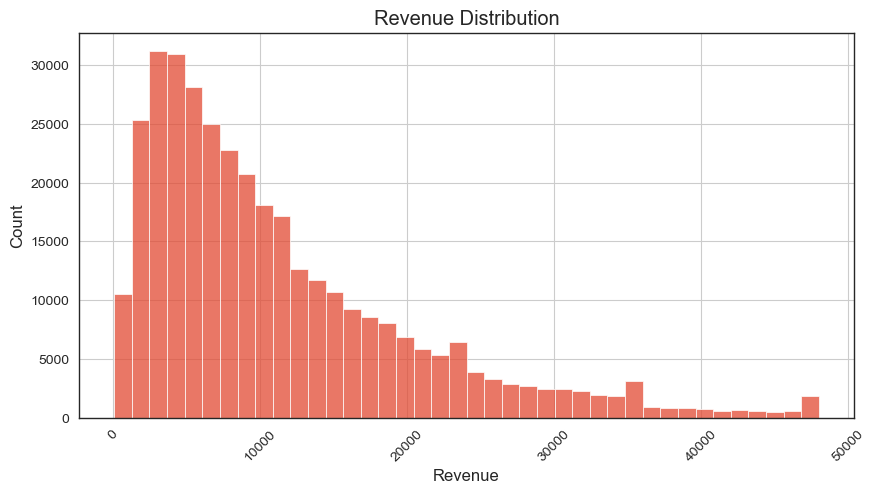

In [14]:
## Revenue distribution
plt.figure(figsize=(10,5))

sns.histplot(
    sales["Revenue"],
    bins=40
)

plt.grid(True)

plt.title("Revenue Distribution")


plt.xticks(rotation=45)

plt.show()

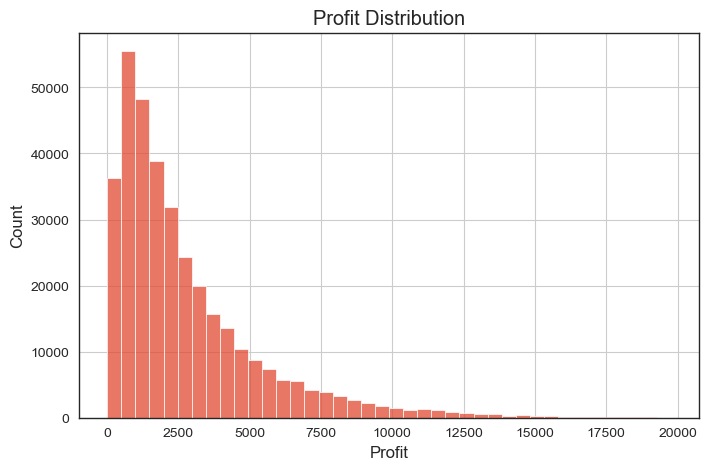

In [15]:
## profit distribution
plt.figure(figsize=(8,5))

sns.histplot(
    sales["Profit"],
    bins=40
)
plt.grid(True)

plt.title("Profit Distribution")

plt.show()

### section 2 : Sales analysis

##### Analyze sales performance to identify revenue trends, high-performing regions, categories, and products, enabling better business and marketing decisions.

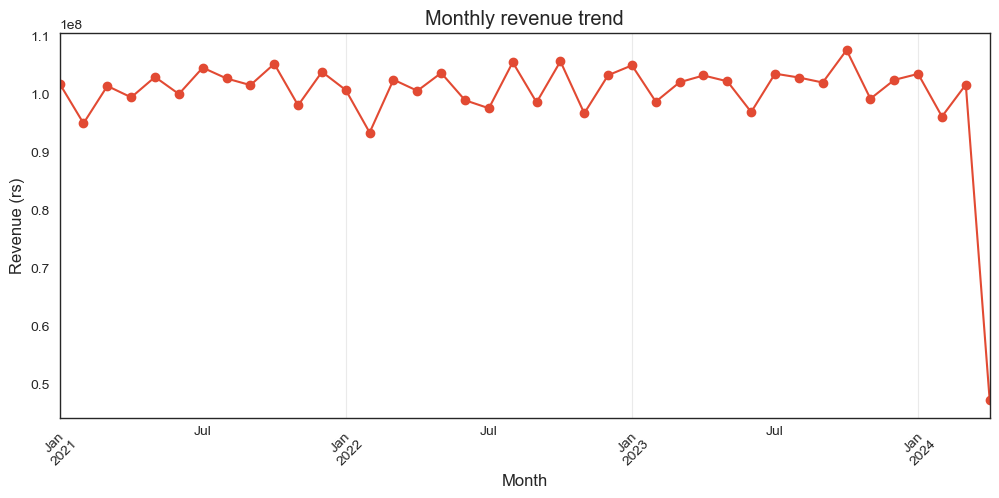

In [16]:
# Analyze sales performance to identify revenue trends, high-performing regions, categories, and products, enabling better business and marketing decisions.
#Q1: How has monthly revenue changed over time?


sales_trend = (
    order_items.merge(
        orders[["order_id", "order_date"]],
        on = "order_id",
        how= "left"
    )
)

#create month column
sales_trend["order_date"]= pd.to_datetime(sales_trend["order_date"])
sales_trend["Month"] = sales_trend["order_date"].dt.to_period("M")

#calculating monthly sales
monthly_sales = (
    sales_trend.groupby("Month")["line_revenue"].sum()
)

#visualization
plt.figure(figsize=(12,5))
monthly_sales.plot(marker="o")

plt.grid(axis="x", linestyle="-", alpha=0.4)

plt.title("Monthly revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue (rs)")
plt.xticks(rotation = 45)

plt.show()

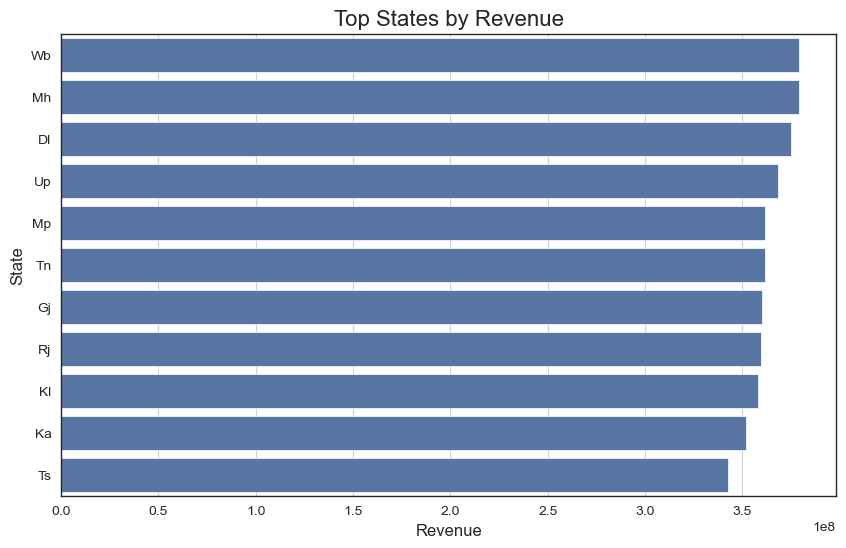

In [17]:
#Q2 : Which state generates the highest revenue

state_sales = (
    order_items.merge(
        orders[["order_id", "customer_id"]],
        on = "order_id"
    )
    .merge(
        customers[["customer_id", "customer_state"]],
        on= "customer_id"
    )
)

state_revenue = (
    state_sales.groupby("customer_state")["line_revenue"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_revenue.values,
    y=state_revenue.index,
    color="#4C72B0"
)
plt.grid(axis="x", linestyle='-', alpha=0.9)
plt.title("Top States by Revenue", fontsize=16)
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("State", fontsize=12)

plt.show()

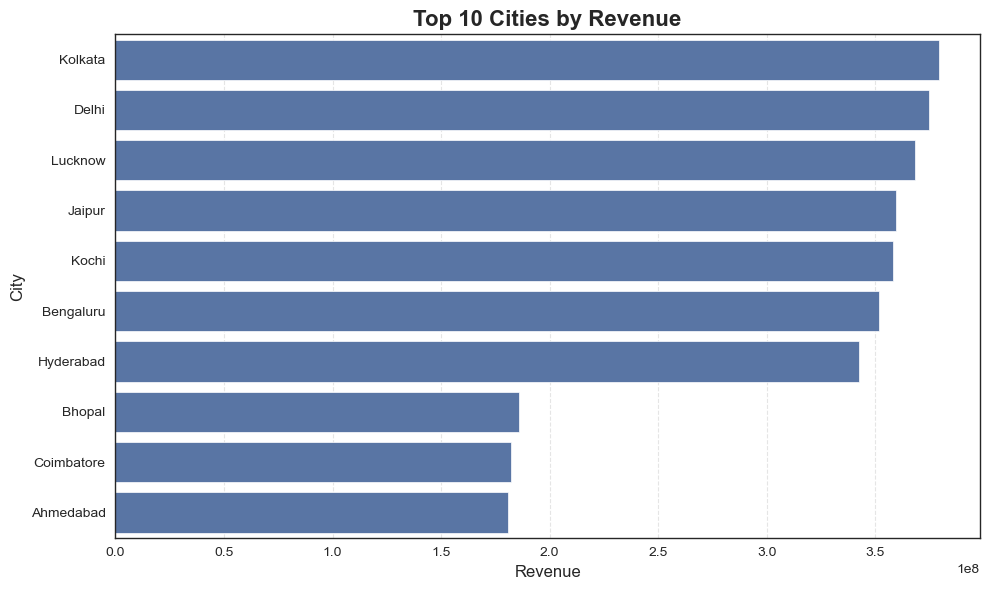

In [18]:
#Q3 : Which cities contributes the most revenue?
# top 10 cities
state_sales = (
    order_items.merge(
        orders[["order_id", "customer_id"]],
        on = "order_id"
    )
    .merge(
        customers[["customer_id", "customer_city"]],
        on= "customer_id"
    )
)

state_revenue = (
    state_sales.groupby("customer_city")["line_revenue"].sum().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_revenue.values,
    y=state_revenue.index,
    color="#4C72B0"
)


plt.title("Top 10 Cities by Revenue", fontsize=16,
    fontweight="bold")
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("City", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

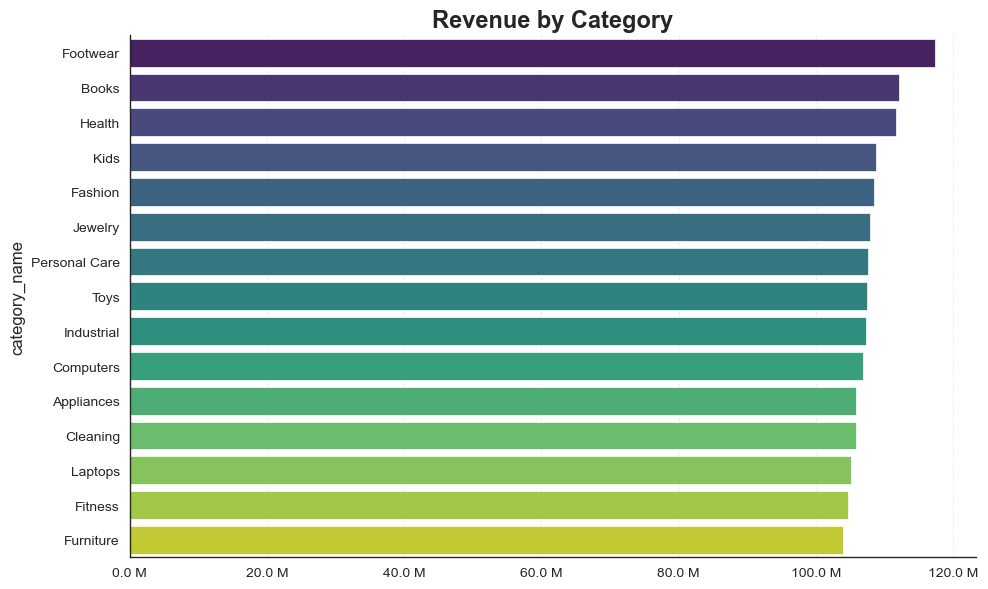

In [19]:
#Q4 : Which product category generate the highest revenue?
# identify the categories that contributes the most to overall revenue.
from matplotlib.ticker import FuncFormatter
category_sales = (
    order_items.merge(
        products[["product_id", "category_id"]],
        on= "product_id"
    )
    .merge(
        categories,
        on = "category_id"
    )
)

category_revenue = (
    category_sales.groupby("category_name")["line_revenue"].sum().sort_values(ascending= False).head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    hue=category_revenue.index,
    palette="viridis",
    legend = False
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x/1e6:.1f} M')
)

plt.title(
    "Revenue by Category",
    fontsize=17,
    fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

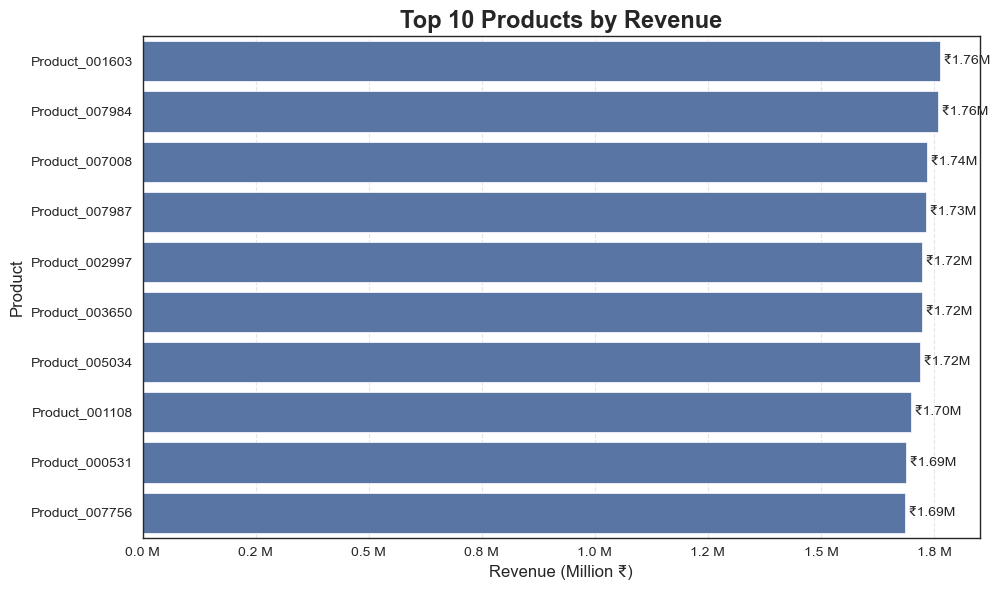

In [20]:
#Q5 :Which product generates the highest revenue?

product_sales = (
    order_items
    .merge(
        products[["product_id", "product_name"]],
        on="product_id"
    )
)

top_products = (
    product_sales
    .groupby("product_name")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=top_products.values,
    y=top_products.index,
    color="#4C72B0"
)


plt.title(
    "Top 10 Products by Revenue",
    fontsize=17,
    fontweight="bold"
)
plt.xlabel("Revenue (Million ₹)")
plt.ylabel("Product")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1e6:.1f} M")
)

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

for i, value in enumerate(top_products.values):
    ax.text(value, i, f" ₹{value/1e6:,.2f}M", va="center")


plt.show()

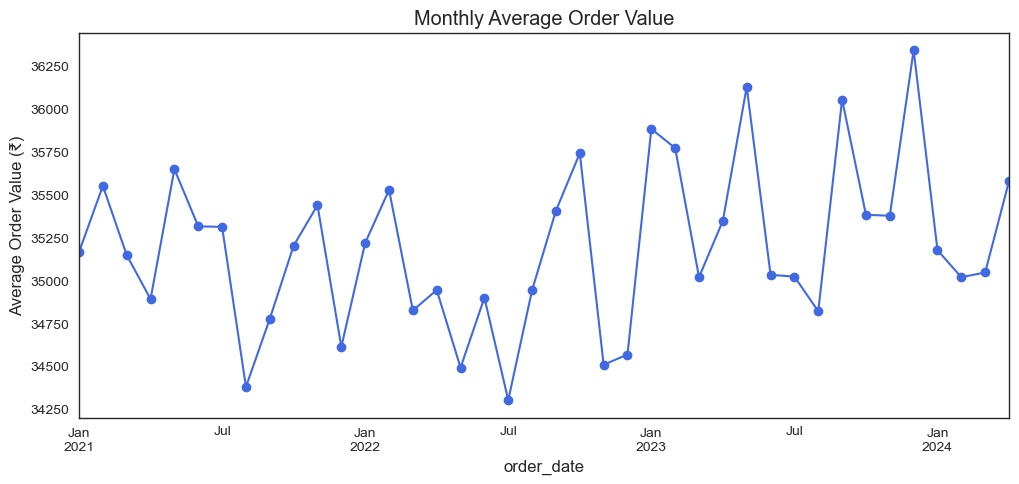

In [21]:
#Q6 Which months have the highest average order value (AOV)?

aov_df = (
    order_items.merge(
        orders[["order_id", "order_date"]],
        on = "order_id"
    )
)

order_revenue = (
    aov_df.groupby(["order_id", aov_df["order_date"].dt.to_period("M")])["line_revenue"].sum().reset_index(name = "Order_Value")
)

monthly_aov = (
    order_revenue
    .groupby("order_date")["Order_Value"]
    .mean()
)

plt.figure(figsize=(12,5))

monthly_aov.plot(marker="o", color="royalblue")

plt.title("Monthly Average Order Value")

plt.ylabel("Average Order Value (₹)")

plt.show()

### section 3 : Customer analysis
##### Analyze customer purchasing behavior, identify valuable customers, understand geographic distribution, and uncover opportunities to improve customer retention and revenue.

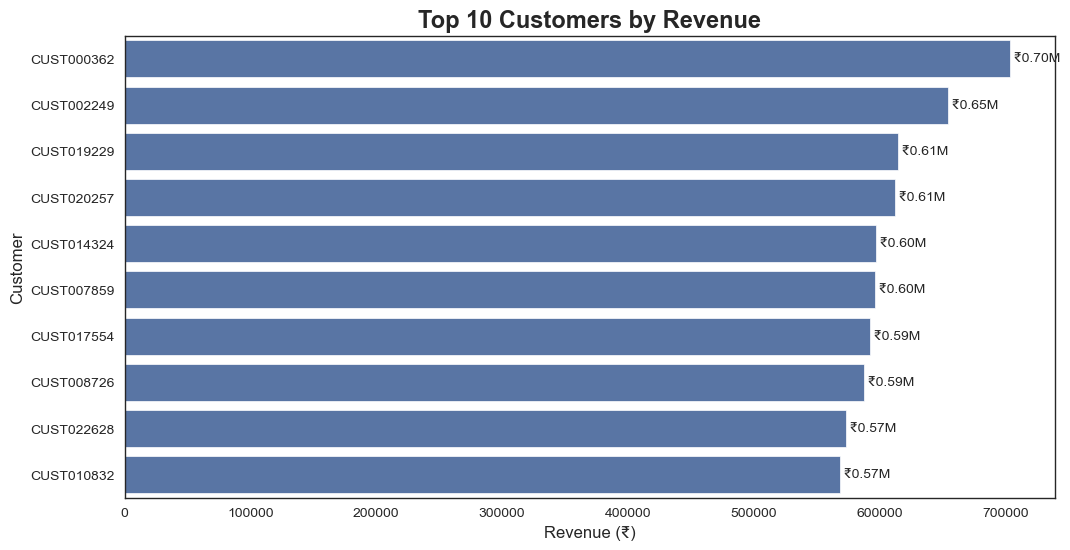

In [22]:
#Q1 Who are the top 10 customers by revenue?
#merge tables
customer_sales = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers["customer_id"],
        on="customer_id",
        how="left"
    )
)

#analysis
top_customers = (
    customer_sales
    .groupby("customer_id")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

#visualization
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    color= "#4C72B0"
)

plt.title("Top 10 Customers by Revenue", fontsize=17,
    fontweight="bold")
plt.xlabel("Revenue (₹)")
plt.ylabel("Customer")

for i, value in enumerate(top_customers.values):
    ax.text(value, i, f" ₹{value/1e6:,.2f}M", va="center")

plt.show()

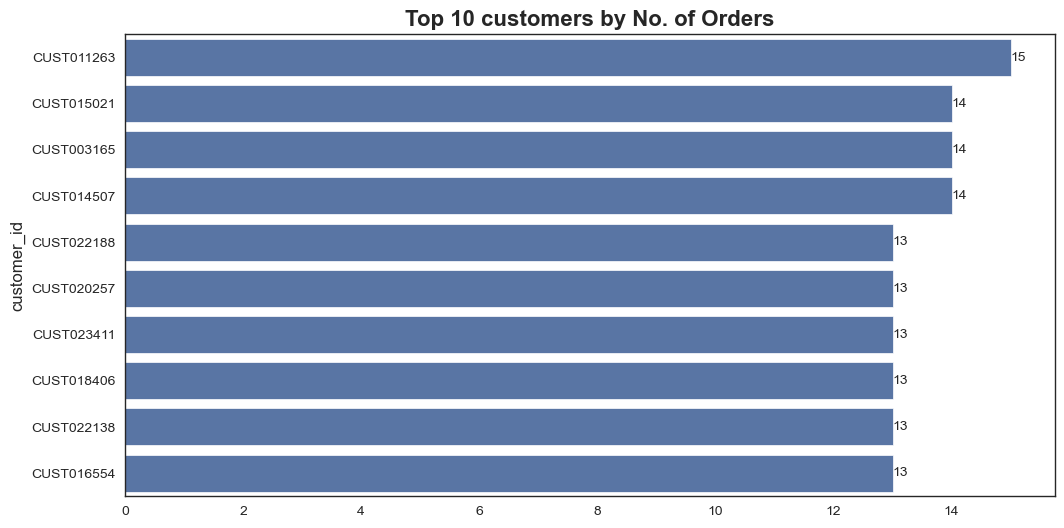

In [23]:
#Q2 Which customers place the highest number of orders?

#merge the tables
customers_orders = (
    orders.merge(customers["customer_id"], on ="customer_id")
)

#analyzing the top 10 customers
top_order_customers = (
    customers_orders.groupby("customer_id")["order_id"].count().sort_values(ascending=False).head(10)
)

#visualizing the top customers by number of orders
plt.figure(figsize=(12,6))
ax = sns.barplot(
    x = top_order_customers.values,
    y = top_order_customers.index,
    color = "#4C72B0"
)

plt.title("Top 10 customers by No. of Orders", fontsize = "16",fontweight = "bold")

for i , value in enumerate(top_order_customers.values):
    ax.text(value , i, str(value), va="center")

plt.show()

In [24]:
#Q3 Which customers have the highest average order value(AOV)?

#merge tables
customer_aov = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id"
    )
    .merge(
        customers["customer_id"],
        on="customer_id"
    )
)

order_value = (
    customer_aov
    .groupby(["customer_id", "order_id"])["line_revenue"]
    .sum()
    .reset_index()
)

##calculating top customers with highest AOV
top_aov = (
    order_value
    .groupby("customer_id")["line_revenue"]
    .mean()
    .reset_index(name="Average_Order_Value")
    .sort_values(by = "Average_Order_Value",ascending=False)
)

top_aov["Average_Order_Value"] = top_aov["Average_Order_Value"].round(2)

top_aov.head(10)


,customer_id,Average_Order_Value
21903,CUST022135,140428.62
1807,CUST001827,131031.49
10991,CUST011107,130388.29
9094,CUST009196,129530.70
12204,CUST012334,122025.55
23925,CUST024185,120965.38
3594,CUST003632,119292.63
2247,CUST002273,116088.15
14337,CUST014488,113974.82
10091,CUST010200,111554.20


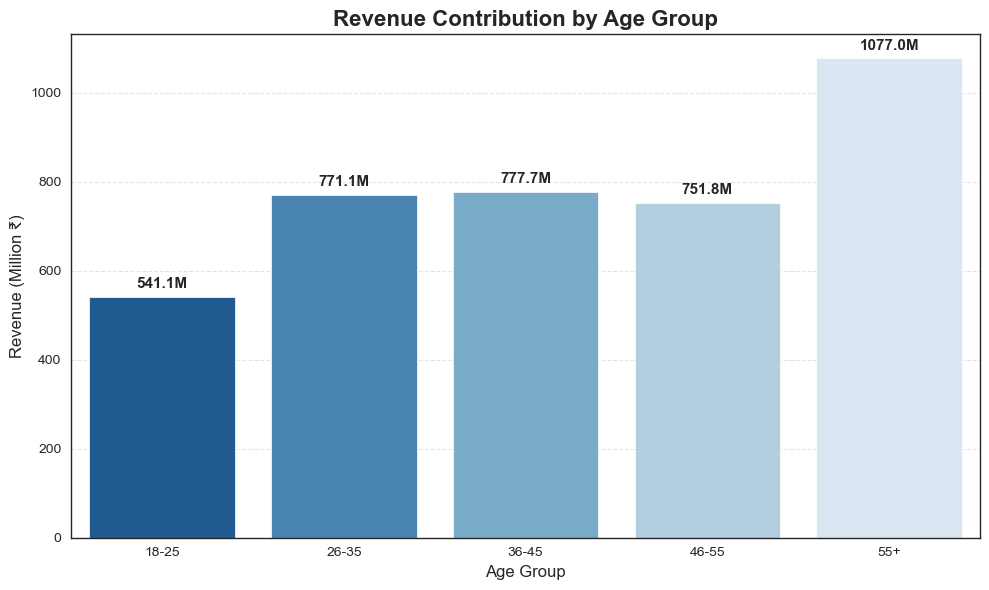

In [25]:
#Q3 Which age group contributes the highest revenue?

cust_age = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id"
    )
    .merge(
        customers[["customer_id", "customer_age"]],
        on="customer_id"
    )
)

## creating age groups
cust_age["Age Group"] = pd.cut(
    cust_age["customer_age"],
    bins=[18,25,35,45,55,100],
    labels=["18-25","26-35","36-45","46-55","55+"]
)

## calculating revenue from a specific age
age_revenue = (
    cust_age
    .groupby("Age Group", observed = False)["line_revenue"]
    .sum()
)
age_revenue_m = age_revenue/1e6

#visualiztion
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=age_revenue_m.index,
    y=age_revenue_m.values,
    hue=age_revenue_m.index,
    palette="Blues_r",
    legend = False
)

plt.title(
    "Revenue Contribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group", fontsize=12)

plt.ylabel("Revenue (Million ₹)", fontsize=12)

# Add value labels
for i, value in enumerate(age_revenue_m.values):
    ax.text(
        i,
        value + 20,
        f"{value:.1f}M",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

### Section 4: Product & Category Analysis
##### Analyze product and category performance to identify top revenue drivers, best-selling products, profitable categories, and opportunities to optimize inventory, pricing, and product strategy.

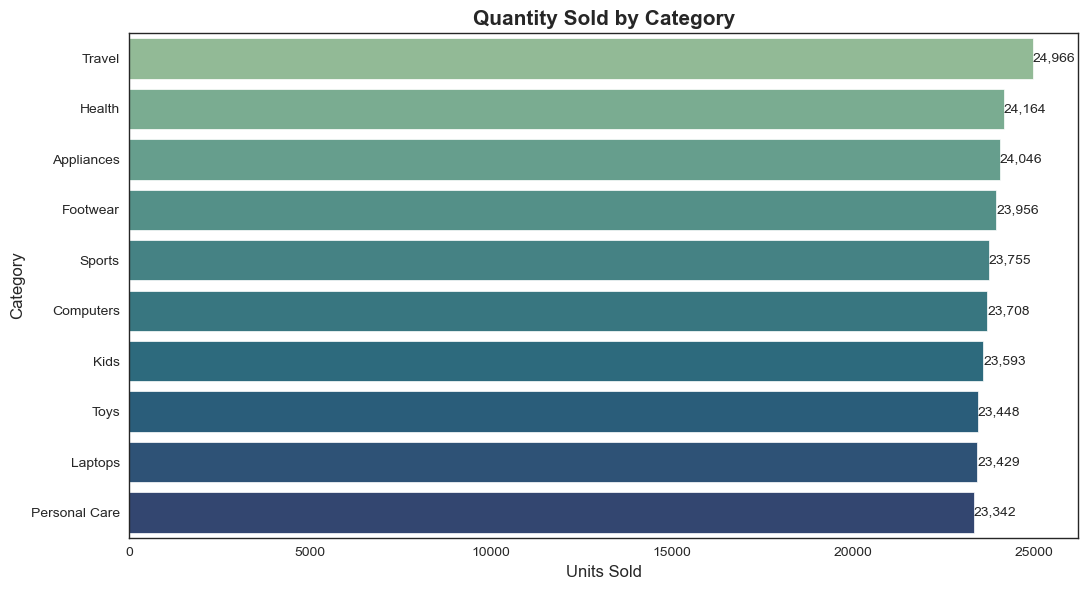

In [26]:
#The analysis of product- and category-level revenue has already been done in sales analysis part, providing insights into the primary revenue drivers.With these insights established, we now move on to the next stage of the analysis.

#Q1 Which categories sell the highest quantity of products?
## identifies categories with the highest customer demand based on units sold

## calculating the total quantity of products sold based on cateogry
category_quantity = (
    category_sales
    .groupby("category_name")["quantity"]
    .sum()
    .sort_values(ascending=False).head(10)
)

#visualization
plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=category_quantity.values,
    y=category_quantity.index,
    hue=category_quantity.index,
    palette="crest",
    legend = False
)

plt.title("Quantity Sold by Category", fontsize=15, fontweight="bold")
plt.xlabel("Units Sold")
plt.ylabel("Category")

for i, value in enumerate(category_quantity.values):
    ax.text(value, i, f"{value:,}", va="center")

plt.tight_layout()
plt.show()

In [27]:
#Q2 Which products have the highest average customer ratings?
# This helps identify products that consistently satisfy customers and can be promoted with confidence.

#merge table to get each product rating 
product_rating = (
    reviews
    .merge(
        products[["product_id","product_name"]],
        on="product_id",
        how="left"
    )
)

# calculate the average rating for a product
top_rated = (
    product_rating
    .groupby("product_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

top_rated.head(20)


product_name
Product_003870    5.0
Product_006004    5.0
Product_002039    5.0
Product_006824    5.0
Product_005424    5.0
Product_001823    5.0
Product_001488    5.0
Product_000305    5.0
Product_001465    5.0
Product_002337    5.0
Product_006680    5.0
Product_002327    5.0
Product_001769    5.0
Product_007391    5.0
Product_002102    5.0
Product_005687    5.0
Product_004500    5.0
Product_004498    5.0
Product_002643    5.0
Product_001670    4.9
Name: rating, dtype: float64

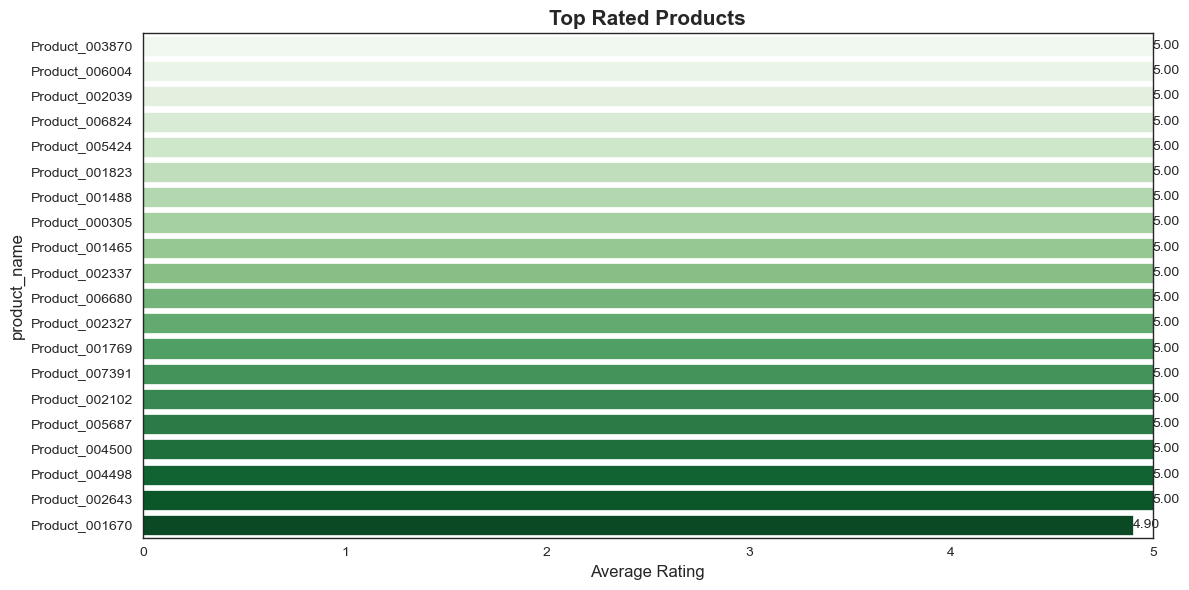

In [28]:
## visualization (products that have the highest average customer rating)
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_rated.values,
    y=top_rated.index,
    hue = top_rated.index,
    palette="Greens"
)

plt.title("Top Rated Products", fontsize=15, fontweight="bold")
plt.xlabel("Average Rating")
plt.xlim(0,5)

for i, value in enumerate(top_rated.values):
    ax.text(value, i, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

In [29]:
# merge products table and category_sales to get the cost price of products
category_sales = category_sales.merge(
    products[["product_id", "cost_price"]],
    on="product_id",
    how="left"
)

In [30]:
category_sales.head()

,order_item_id,order_id,product_id,seller_id,quantity,discount_pct,shipping_charges,selling_price,line_revenue,category_id,category_name,department,cost_price
0,OI000000001,ORD0088068,PROD006904,SEL0352,4,10.04,232.88,2524.30,10330.08,CAT012,Appliances,Auto,1821.36
1,OI000000002,ORD0079822,PROD003468,SEL0372,1,42.16,100.82,2881.73,2982.55,CAT004,Home & Kitchen,Daily Needs,1981.85
2,OI000000003,ORD0117893,PROD006686,SEL0249,4,44.15,92.01,4323.13,17384.53,CAT027,Fitness,Daily Needs,3272.21
3,OI000000004,ORD0049289,PROD006385,SEL0228,2,31.56,180.80,3009.88,6200.56,CAT003,Fashion,Kids,1838.39
4,OI000000005,ORD0083584,PROD002068,SEL0257,1,29.75,200.19,5835.03,6035.22,CAT034,Tools,Entertainment,3835.93


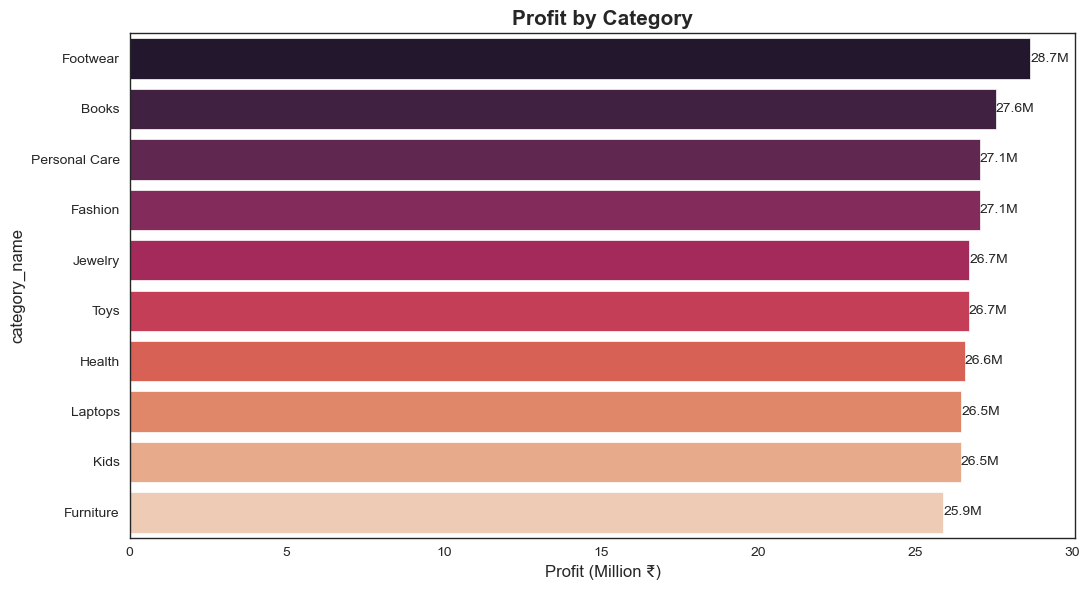

In [31]:
#Q3 Which categories generate the highest profit?
#This analysis identifies the most profitable product categories.

#calculating profit
category_profit = (
    category_sales
    .assign(
        Profit=lambda x: (
            (x["selling_price"] - x["cost_price"]) * x["quantity"]
        )
    )
    .groupby("category_name")["Profit"]
    .sum()
    .sort_values(ascending=False).head(10)
)

category_profit_million = category_profit / 1e6

#visualization
plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=category_profit_million.values,
    y=category_profit_million.index,
    hue = category_profit_million.index,
    palette="rocket"
)

plt.title("Profit by Category", fontsize=15, fontweight="bold")
plt.xlabel("Profit (Million ₹)")

for i, value in enumerate(category_profit_million.values):
    ax.text(value, i, f"{value:.1f}M", va="center")

plt.tight_layout()
plt.show()

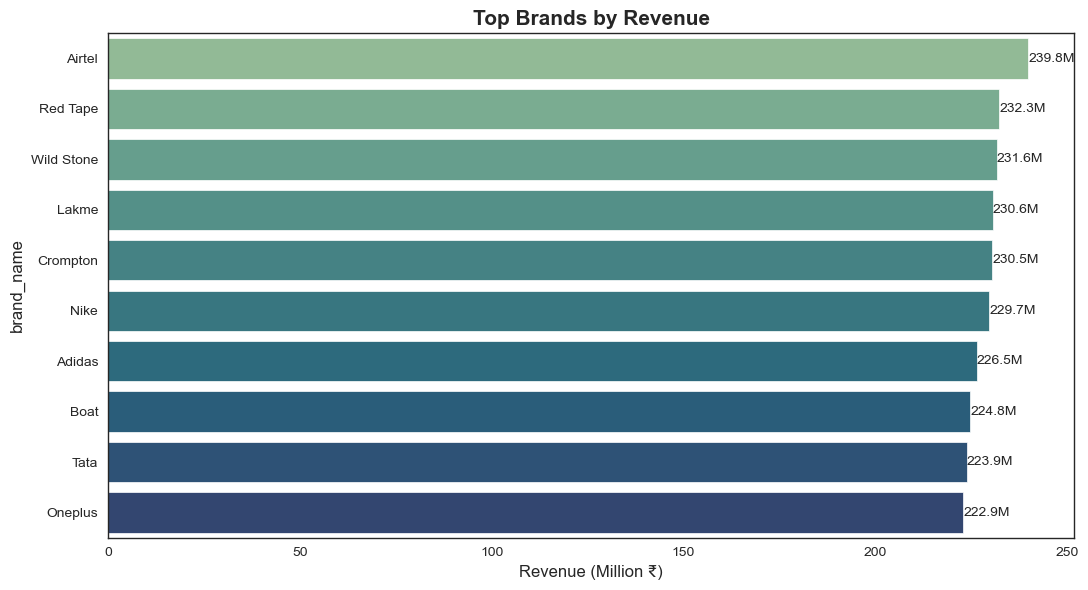

In [32]:
#Q4 : Which brands generate the highest revenue?
# Brand performance helps identify strategic brand partnerships and understand which brands customers prefer.

#calculating sales based on the brand_name
brand_sales = (
    product_sales
    .merge(
        products[["product_id","brand_name"]],
        on="product_id",
        how="left"
    )
)

#calcuate brand revenue
brand_revenue = (
    brand_sales
    .groupby("brand_name")["line_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

brand_revenue_million = brand_revenue / 1e6

#visualization
plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=brand_revenue_million.values,
    y=brand_revenue.index,
    hue = brand_revenue.index,
    palette="crest"
)

plt.title("Top Brands by Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Revenue (Million ₹)")

for i, value in enumerate(brand_revenue_million.values):
    ax.text(value, i, f"{value:.1f}M", va="center")

plt.tight_layout()
plt.show()

#### Section 5 : Return analysis

##### Evaluate delivery efficiency and return patterns to identify operational bottlenecks, improve customer satisfaction, and reduce return-related costs.

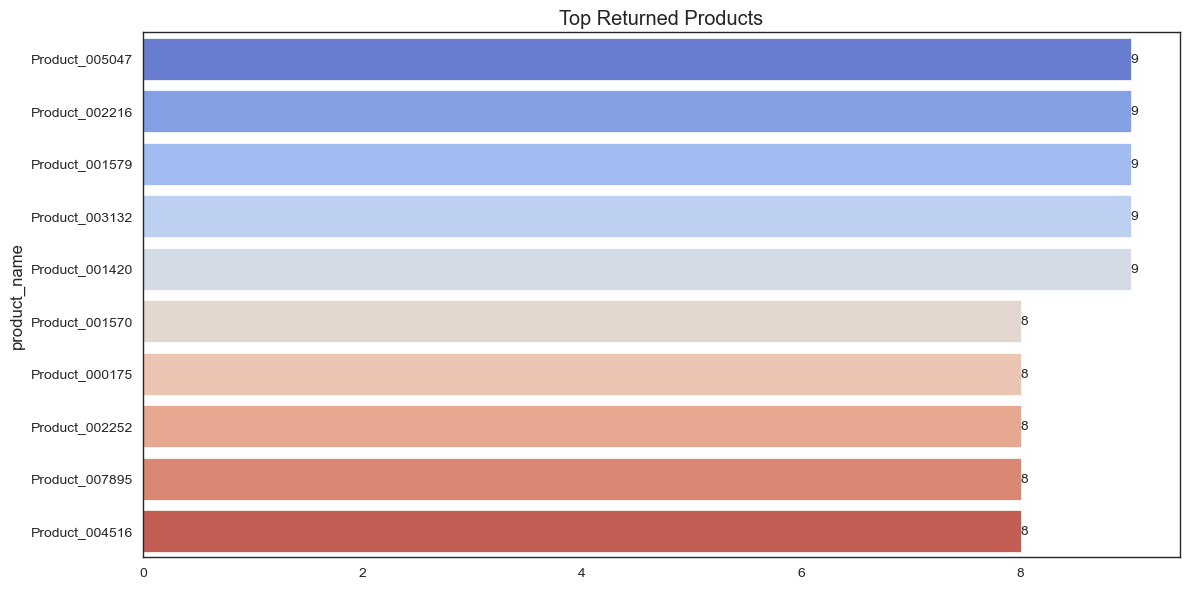

In [33]:
#Q1 Which products have the highest return count?
## identify products that may have quality issues or fail to meet customer expectations.

return_products = (
    returns
    .merge(
        products[["product_id", "product_name"]],
        on="product_id",
        how="left"
    )
)

top_return_products = (
    return_products
    .groupby("product_name")["return_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_return_products.values,
    y=top_return_products.index,
    hue = top_return_products.index,
    palette="coolwarm"
)

plt.title("Top Returned Products")

for i, value in enumerate(top_return_products.values):
    ax.text(value, i, str(value), va="center")

plt.tight_layout()
plt.show()

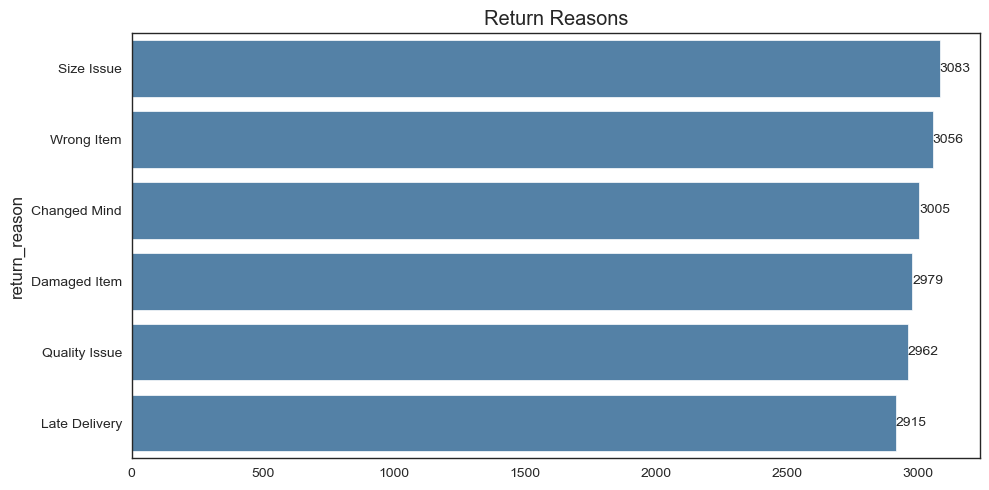

In [34]:
#Q2 What are the most common return reasons?
## Understanding why customers return products helps reduce avoidable returns and improve the customer experience.

return_reason = (
    returns["return_reason"]
    .value_counts()
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=return_reason.values,
    y=return_reason.index,
    color = "steelblue"
)

plt.title("Return Reasons")

for i, value in enumerate(return_reason.values):
    ax.text(value, i, str(value), va="center")

plt.tight_layout()
plt.show()

Overall Return Rate : 5.14%


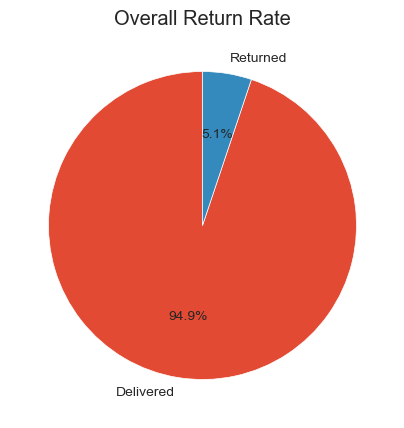

In [35]:
#Q3 What is the overall return rate?
## Return rate is a key marketplace KPI that reflects customer satisfaction and product quality.

total_order_items = order_items["order_item_id"].nunique()

total_returns = returns["return_id"].nunique()

return_rate = (
    total_returns / total_order_items
) * 100

print(f"Overall Return Rate : {return_rate:.2f}%")

return_summary = pd.DataFrame({
    "Status":["Delivered","Returned"],
    "Count":[
        total_order_items-total_returns,
        total_returns
    ]
})

plt.figure(figsize=(5,5))

plt.pie(
    return_summary["Count"],
    labels=return_summary["Status"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Return Rate")

plt.show()

#### Section 7 : Review Analysis

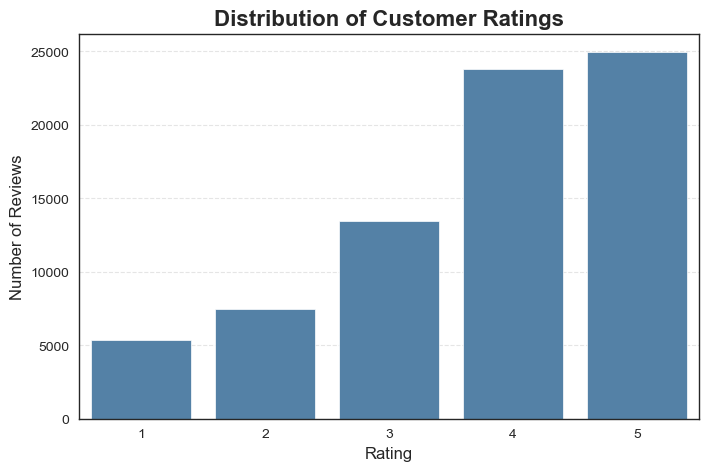

In [36]:
#Q1 : What is the overall distribution of customer ratings?
## Customer ratings reflect overall satisfaction with products and services.
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x='rating',
    color = "steelblue"
)

plt.title("Distribution of Customer Ratings", fontsize = 16, fontweight = "bold")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

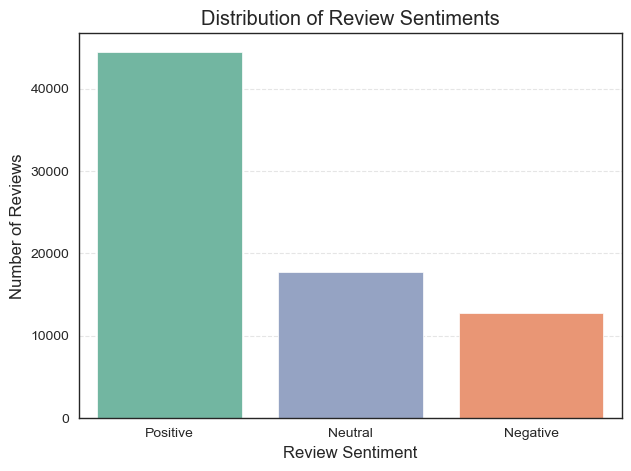

In [37]:
#Q2 : What is the distribution of review sentiments?
## Review sentiment helps understand customers' opinions beyond ratings and measures the overall perception of products and services.

plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews,
    x='review_sentiment',
    order=reviews['review_sentiment'].value_counts().index,
    hue = 'review_sentiment',
    palette='Set2'
)

plt.title("Distribution of Review Sentiments")
plt.xlabel("Review Sentiment")
plt.ylabel("Number of Reviews")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

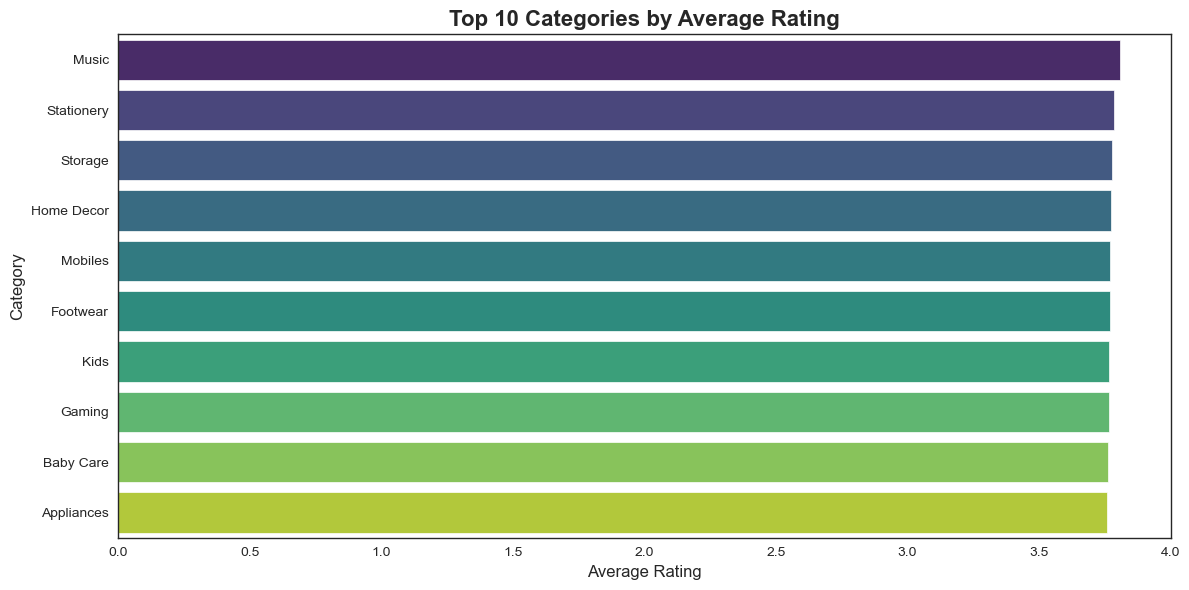

In [38]:
#Q3 Which product categories receive the highest average ratings?
## This identifies product categories that consistently satisfy customers and highlights categories that may require improvements.

review_category = (
    reviews
    .merge(products[['product_id','category_id']], on='product_id')
    .merge(categories, on='category_id')
)

avg_rating = (
    review_category
    .groupby('category_name')['rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index,
    hue = avg_rating.index,
    palette='viridis',
    legend = False
)

plt.title("Top 10 Categories by Average Rating", fontsize = 16, fontweight = "bold")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.show()